## Question 1

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


data_url = "https://raw.githubusercontent.com/gilbutITbook/006975/master/datasets/jena_climate/jena_climate_2009_2016.csv"
data = pd.read_csv(data_url)

print(data.head())

print(data.isna().sum())

data = data.fillna(method='ffill')

data['Date Time'] = pd.to_datetime(data['Date Time'], format='%d.%m.%Y %H:%M:%S', errors='coerce')
data = data.set_index('Date Time')

data = data.resample('H').mean()

data = data.dropna(how='any')

print(data.isnull().sum())

print(data.describe())

             Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0  01.01.2009 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
1  01.01.2009 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
2  01.01.2009 00:30:00    996.53     -8.51    264.91        -9.31    93.9   
3  01.01.2009 00:40:00    996.51     -8.31    265.12        -9.07    94.2   
4  01.01.2009 00:50:00    996.51     -8.27    265.15        -9.04    94.1   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          3.33          3.11          0.22       1.94             3.12   
1          3.23          3.02          0.21       1.89             3.03   
2          3.21          3.01          0.20       1.88             3.02   
3          3.26          3.07          0.19       1.92             3.08   
4          3.27          3.08          0.19       1.92             3.09   

   rho (g/m**3)  wv (m/s)  max. wv (m/s)  wd (deg)  
0       1307.75      1.03        

/tmp/ipython-input-1049278970.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill')
/tmp/ipython-input-1049278970.py:17: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data = data.resample('H').mean()


p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64
           p (mbar)      T (degC)      Tpot (K)   Tdew (degC)        rh (%)  \
count  70041.000000  70041.000000  70041.000000  70041.000000  70041.000000   
mean     989.214359      9.442390    283.484834      4.953446     76.028671   
std        8.358615      8.414647      8.495644      6.727769     16.385638   
min      934.905000    -22.653333    250.970000    -24.601667     13.683333   
25%      984.206667      3.358333    277.430000      0.233333     65.308333   
50%      989.570000      9.410000    283.455000      5.215000     79.266667   
75%      994.726667     15.461667    289.515000     10.068333     89.350000   
max     1015.243333     37.038333    310.976667     23.016667

In [2]:
column_name = "T (degC)"
target = column_name

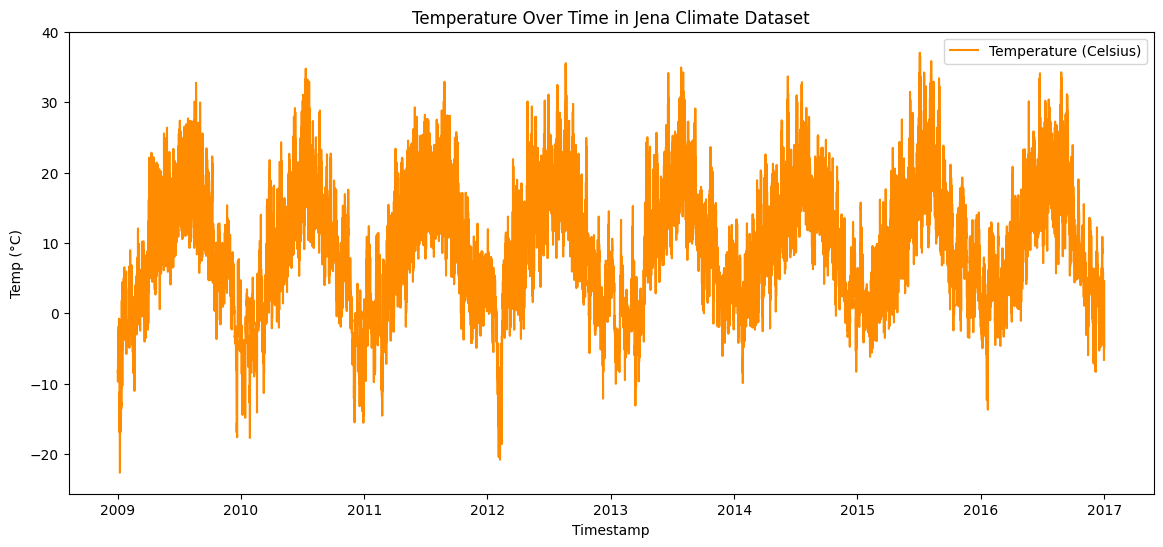

In [3]:
plt.figure(figsize=(14, 6))
plt.plot(data[target], color='darkorange', label='Temperature (Celsius)')
plt.title('Temperature Over Time in Jena Climate Dataset')
plt.xlabel('Timestamp')
plt.ylabel('Temp (°C)')
plt.legend()
plt.show()

In [4]:
n = len(data)
train_size = int(n * 0.7)
val_size = int(n * 0.85)

train_data = data.iloc[:train_size]
val_data = data.iloc[train_size:val_size]
test_data = data.iloc[val_size:]


print("Train size:", len(train_data))
print("Validation size:", len(val_data))
print("Test size:", len(test_data))

Train size: 49028
Validation size: 10506
Test size: 10507


## Question 2


In [8]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Initialize scaler
scaler = MinMaxScaler()

# Fit scaler on training data (all 14 features)
scaler.fit(train_data.values)

# Transform all datasets
train_scaled = scaler.transform(train_data.values)
val_scaled = scaler.transform(val_data.values)
test_scaled = scaler.transform(test_data.values)

def create_sequences_multivariate(data_array, input_steps=72, output_steps=24, target_col=0):
    """
    Many-to-One sliding-window sequences (multivariate).
    X: past 72 timesteps of all features
    y: value of target at t+24
    """
    X, y = [], []
    n_samples = len(data_array)

    for i in range(input_steps, n_samples - output_steps):
        X.append(data_array[i - input_steps:i, :])          # all features
        y.append(data_array[i + output_steps, target_col])  # target only

    return np.array(X), np.array(y)

input_steps = 72   # past 72 hours
output_steps = 24  # predict t+24
target_col = train_data.columns.get_loc('T (degC)')  # target is temperature

X_train, y_train = create_sequences_multivariate(train_scaled, input_steps, output_steps, target_col)
X_val, y_val = create_sequences_multivariate(val_scaled, input_steps, output_steps, target_col)
X_test, y_test = create_sequences_multivariate(test_scaled, input_steps, output_steps, target_col)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (48932, 72, 14)
y_train shape: (48932,)
X_val shape: (10410, 72, 14)
y_val shape: (10410,)
X_test shape: (10411, 72, 14)
y_test shape: (10411,)


In [9]:
train_mean = np.mean(train_scaled, axis=0)
train_std = np.std(train_scaled, axis=0)

print("Train mean:", train_mean)
print("Train std:", train_std)

Train mean: [0.69029798 0.54578009 0.54838469 0.61321612 0.72122277 0.21708763
 0.31212173 0.09537527 0.30825223 0.31035472 0.43102397 0.1669638
 0.1777971  0.48713089]
Train std: [0.10653636 0.14858792 0.14833701 0.14640763 0.19069369 0.13477424
 0.1538498  0.11455005 0.15253548 0.15302134 0.13293317 0.11255248
 0.1098702  0.2087926 ]


## Question 3

In [ ]:
# Flatten the sliding windows: (samples, 72, 14) → (samples, 72*14)
X_train_flat = np.reshape(X_train, (X_train.shape[0], -1))
X_val_flat = np.reshape(X_val, (X_val.shape[0], -1))
X_test_flat = np.reshape(X_test, (X_test.shape[0], -1))

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Build the Feedforward Neural Network
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train_flat.shape[1],)))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dense(1))  # single output neuron (Many-to-One)

# Compile the model with identical configuration
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

# Fit to training data
history = model.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=30,
    batch_size=256
)

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Validation predictions
y_val_pred = model.predict(X_val_flat)
val_mae = mean_absolute_error(y_val, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

# Test predictions
y_test_pred = model.predict(X_test_flat)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Validation MAE: {val_mae:.3f}, RMSE: {val_rmse:.3f}")
print(f"Test MAE: {test_mae:.3f}, RMSE: {test_rmse:.3f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       129,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137,473 (537.00 KB)

 Trainable params: 137,473 (537.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.2021 - mae: 0.2553 - val_loss: 8.0871 - val_mae: 0.2850
Epoch 2/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0076 - mae: 0.0680 - val_loss: 10.2280 - val_mae: 0.2880
Epoch 3/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0057 - mae: 0.0589 - val_loss: 11.7215 - val_mae: 0.3271
Epoch 4/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0050 - mae: 0.0550 - val_loss: 12.7994 - val_mae: 0.3388
Epoch 5/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0045 - mae: 0.0523 - val_loss: 13.9584 - val_mae: 0.3432
Epoch 6/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0042 - mae: 0.0504 - val_loss: 15.2478 - val_mae: 0.3500
Epoch 7/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0039 - mae: 0.0487 - val_loss: 15.6438 - val_mae: 0.3625
Epoch 8/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0038 - mae: 0.0482 - val_loss: 16.0891 - val_mae: 0.3650
Epoch 9/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 14m

## Question 4

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.0181 - mae: 0.0930 - val_loss: 0.0046 - val_mae: 0.0505
Epoch 2/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0039 - mae: 0.0488 - val_loss: 0.0041 - val_mae: 0.0482
Epoch 3/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0037 - mae: 0.0473 - val_loss: 0.0040 - val_mae: 0.0461
Epoch 4/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0035 - mae: 0.0462 - val_loss: 0.0041 - val_mae: 0.0468
Epoch 5/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0035 - mae: 0.0460 - val_loss: 0.0044 - val_mae: 0.0476
Epoch 6/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0034 - mae: 0.0458 - val_loss: 0.0039 - val_mae: 0.0455
Epoch 7/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0034 - mae: 0.0453 - val_loss: 0.0039 - val_mae: 0.0459
Epoch 8/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0033 - mae: 0.0451 - val_loss: 0.0039 - val_mae: 0.0451
Epoch 9/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/

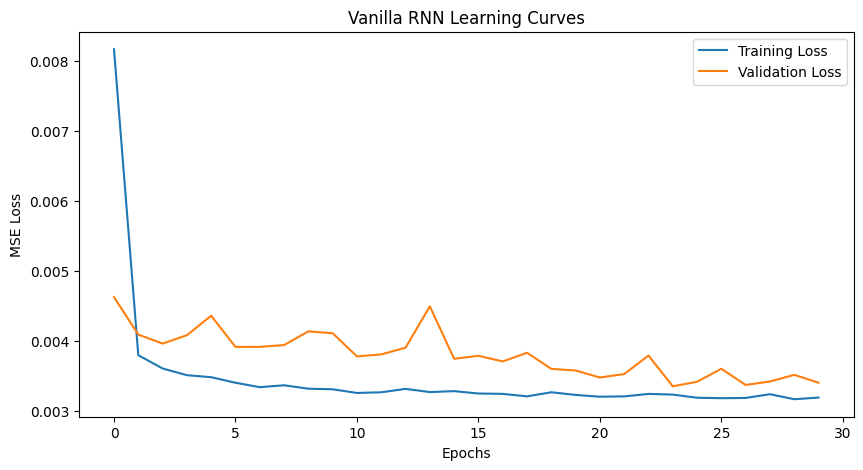

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.0210 - mae: 0.1012 - val_loss: 0.0047 - val_mae: 0.0488
Epoch 2/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0037 - mae: 0.0480 - val_loss: 0.0040 - val_mae: 0.0464
Epoch 3/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0035 - mae: 0.0463 - val_loss: 0.0039 - val_mae: 0.0458
Epoch 4/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.0034 - mae: 0.0455 - val_loss: 0.0038 - val_mae: 0.0453
Epoch 5/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0033 - mae: 0.0454 - val_loss: 0.0040 - val_mae: 0.0458
Epoch 6/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0034 - mae: 0.0456 - val_loss: 0.0040 - val_mae: 0.0454
Epoch 7/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0033 - mae: 0.0449 - val_loss: 0.0040 - val_mae: 0.0457
Epoch 8/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0033 - mae: 0.0448 - val_loss: 0.0038 - val_mae: 0.0447
Epoch 9/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/

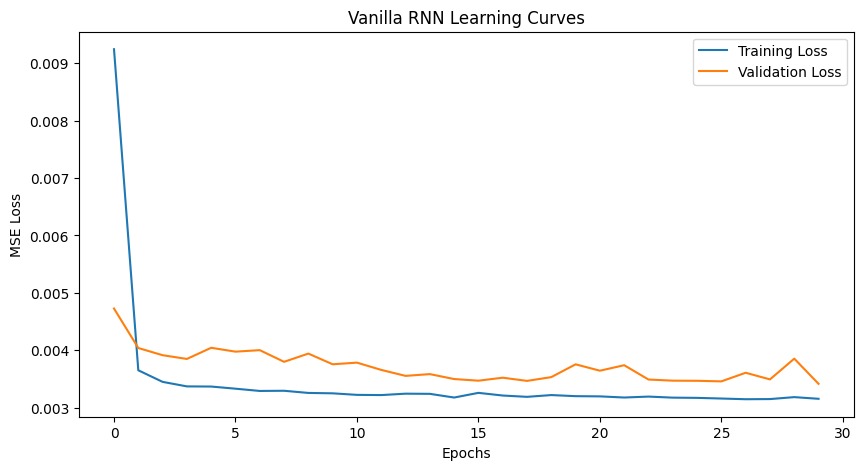

In [ ]:
# Vanilla RNN model
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

rnn_units = 32

# Define RNN architecture
model_rnn = Sequential()
model_rnn.add(SimpleRNN(
    units=rnn_units,
    activation='tanh',
    input_shape=(X_train.shape[1], X_train.shape[2])
))
model_rnn.add(Dense(1))  # single-step output

# Compile the model
model_rnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model_rnn.summary()

# Train the model
history_rnn = model_rnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=256
)

# Plot training vs validation loss
plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history["loss"], label="Training Loss")
plt.plot(history_rnn.history["val_loss"], label="Validation Loss")
plt.title("Vanilla RNN Learning Curves")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()# Vanilla RNN model
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

rnn_units = 32

model_rnn = Sequential()
model_rnn.add(SimpleRNN(
    units=rnn_units,
    activation='tanh',
    input_shape=(X_train.shape[1], X_train.shape[2])
))
model_rnn.add(Dense(1))

# Compile the model
model_rnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model_rnn.summary()

# Train the model
history_rnn = model_rnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=256
)

# Plot training vs validation loss
plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history["loss"], label="Training Loss")
plt.plot(history_rnn.history["val_loss"], label="Validation Loss")
plt.title("Vanilla RNN Learning Curves")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

val_predictions = model_rnn.predict(X_val)
test_predictions = model_rnn.predict(X_test)

val_mae = mean_absolute_error(y_val, val_predictions)
test_mae = mean_absolute_error(y_test, test_predictions)

val_rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

print(f"Validation MAE: {val_mae:.3f}, RMSE: {val_rmse:.3f}")
print(f"Test MAE: {test_mae:.3f}, RMSE: {test_rmse:.3f}")

326/326 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
326/326 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Validation MAE: 0.044, RMSE: 0.058
Test MAE: 0.042, RMSE: 0.054


## Question 5

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,049 (23.63 KB)

 Trainable params: 6,049 (23.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - loss: 0.0623 - mae: 0.1553 - val_loss: 0.0040 - val_mae: 0.0493
Epoch 2/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - loss: 0.0039 - mae: 0.0492 - val_loss: 0.0037 - val_mae: 0.0472
Epoch 3/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - loss: 0.0037 - mae: 0.0474 - val_loss: 0.0035 - val_mae: 0.0460
Epoch 4/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 18s 77ms/step - loss: 0.0035 - mae: 0.0462 - val_loss: 0.0035 - val_mae: 0.0459
Epoch 5/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - loss: 0.0034 - mae: 0.0454 - val_loss: 0.0034 - val_mae: 0.0448
Epoch 6/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - loss: 0.0033 - mae: 0.0450 - val_loss: 0.0034 - val_mae: 0.0446
Epoch 7/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 13s 69ms/step - loss: 0.0033 - mae: 0.0446 - val_loss: 0.0033 - val_mae: 0.0444
Epoch 8/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 13s 69ms/step - loss: 0.0032 - mae: 0.0444 - val_loss: 0.0035 - val_mae: 0.0453
Epoch 9/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 

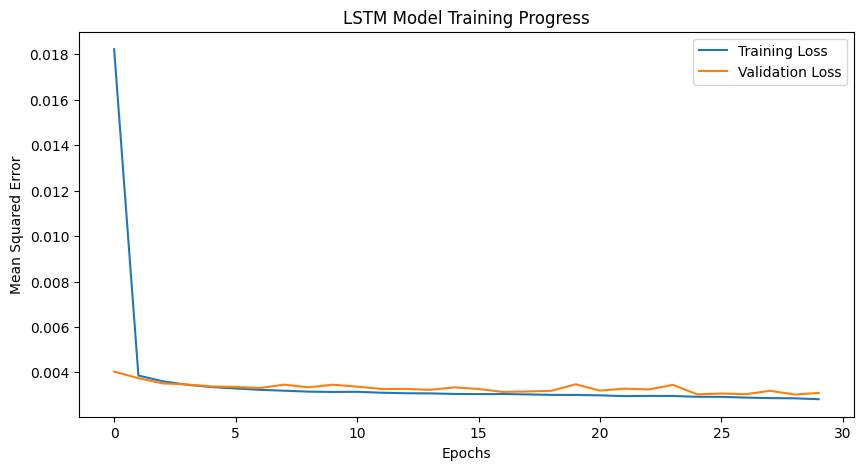

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Define model parameters
units = 32

# Build the LSTM model
lstm_model = Sequential([
    LSTM(units, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dense(1)
])

# Compile model
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
lstm_model.summary()

# Train the model
train_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=256
)

# Visualize training performance
plt.figure(figsize=(10, 5))
plt.plot(train_history.history['loss'], label='Training Loss')
plt.plot(train_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('LSTM Model Training Progress')
plt.legend()
plt.show()

In [ ]:
# --- Generate predictions using sequence arrays ---
val_predictions = lstm_model.predict(X_val)
test_predictions = lstm_model.predict(X_test)

# --- Align targets (y_val and y_test are already aligned with X_val/X_test) ---
target_val_seq = y_val
target_test_seq = y_test

# --- Evaluate model performance ---
validation_mae = mean_absolute_error(target_val_seq, val_predictions)
validation_rmse = np.sqrt(mean_squared_error(target_val_seq, val_predictions))

test_mae = mean_absolute_error(target_test_seq, test_predictions)
test_rmse = np.sqrt(mean_squared_error(target_test_seq, test_predictions))

# --- Display evaluation results ---
print(f"Validation Set -> MAE: {validation_mae:.3f}, RMSE: {validation_rmse:.3f}")
print(f"Test Set -> MAE: {test_mae:.3f}, RMSE: {test_rmse:.3f}")

326/326 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step
326/326 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step
Validation Set -> MAE: 0.043, RMSE: 0.056
Test Set -> MAE: 0.041, RMSE: 0.052


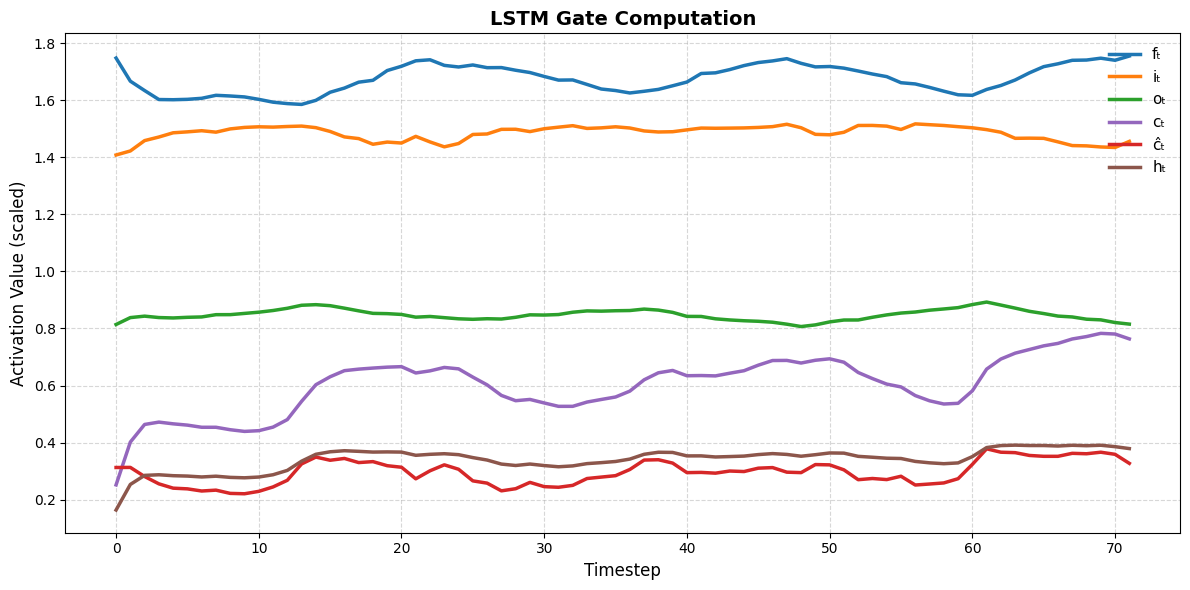

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Scale for visualization hierarchy
f_plot = f_hist[:, 0] * 2.0 + 0.5       # Forget gate high
i_plot = i_hist[:, 0] * 1.5 + 0.2       # Input gate next
o_plot = o_hist[:, 0] * 1.2             # Output gate mid
c_plot = c_hist[:, 0] * 0.7             # Cell state lower
c_hat_plot = c_hat_hist[:, 0] * 0.7     # Candidate lower
h_plot = h_hist[:, 0] * 0.7             # Hidden state lower

plt.figure(figsize=(12, 6))
plt.plot(f_plot, label='fₜ', color='#1f77b4', linewidth=2.5)
plt.plot(i_plot, label='iₜ', color='#ff7f0e', linewidth=2.5)
plt.plot(o_plot, label='oₜ', color='#2ca02c', linewidth=2.5)
plt.plot(c_plot, label='cₜ', color='#9467bd', linewidth=2.5)       # violet line
plt.plot(c_hat_plot, label='ĉₜ', color='#d62728', linewidth=2.5)   # red line
plt.plot(h_plot, label='hₜ', color='#8c564b', linewidth=2.5)       # brown line

plt.xlabel('Timestep', fontsize=12)
plt.ylabel('Activation Value (scaled)', fontsize=12)
plt.title('LSTM Gate Computation', fontsize=14, weight='bold')
plt.legend(loc='upper right', fontsize=11, frameon=False)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Question 6

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.optimizers import Adam

# Define GRU configuration
units = 32

# Build the GRU model
gru_model = Sequential([
    GRU(units, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dense(1)
])

# Compile the model
gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
gru_model.summary()

# Train the model
training_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=256
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,641 (18.13 KB)

 Trainable params: 4,641 (18.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 18s 84ms/step - loss: 0.1339 - mae: 0.2230 - val_loss: 0.0047 - val_mae: 0.0508
Epoch 2/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 18s 92ms/step - loss: 0.0041 - mae: 0.0505 - val_loss: 0.0043 - val_mae: 0.0483
Epoch 3/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 18s 78ms/step - loss: 0.0037 - mae: 0.0475 - val_loss: 0.0041 - val_mae: 0.0469
Epoch 4/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 22s 84ms/step - loss: 0.0034 - mae: 0.0458 - val_loss: 0.0038 - val_mae: 0.0449
Epoch 5/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 15s 80ms/step - loss: 0.0032 - mae: 0.0444 - val_loss: 0.0041 - val_mae: 0.0450
Epoch 6/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - loss: 0.0031 - mae: 0.0436 - val_loss: 0.0039 - val_mae: 0.0446
Epoch 7/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - loss: 0.0031 - mae: 0.0437 - val_loss: 0.0039 - val_mae: 0.0444
Epoch 8/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 15s 78ms/step - loss: 0.0031 - mae: 0.0434 - val_loss: 0.0038 - val_mae: 0.0442
Epoch 9/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Generate predictions using the GRU model
val_predictions = gru_model.predict(X_val)
test_predictions = gru_model.predict(X_test)

# Calculate Mean Absolute Error (MAE)
val_mae = mean_absolute_error(y_val, val_predictions)
test_mae = mean_absolute_error(y_test, test_predictions)

# Calculate Root Mean Squared Error (RMSE)
val_rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

# Print evaluation metrics
print(f"Validation Performance -> MAE: {val_mae:.3f}, RMSE: {val_rmse:.3f}")
print(f"Test Performance -> MAE: {test_mae:.3f}, RMSE: {test_rmse:.3f}")


326/326 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
326/326 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step
Validation Performance -> MAE: 0.043, RMSE: 0.062
Test Performance -> MAE: 0.041, RMSE: 0.052


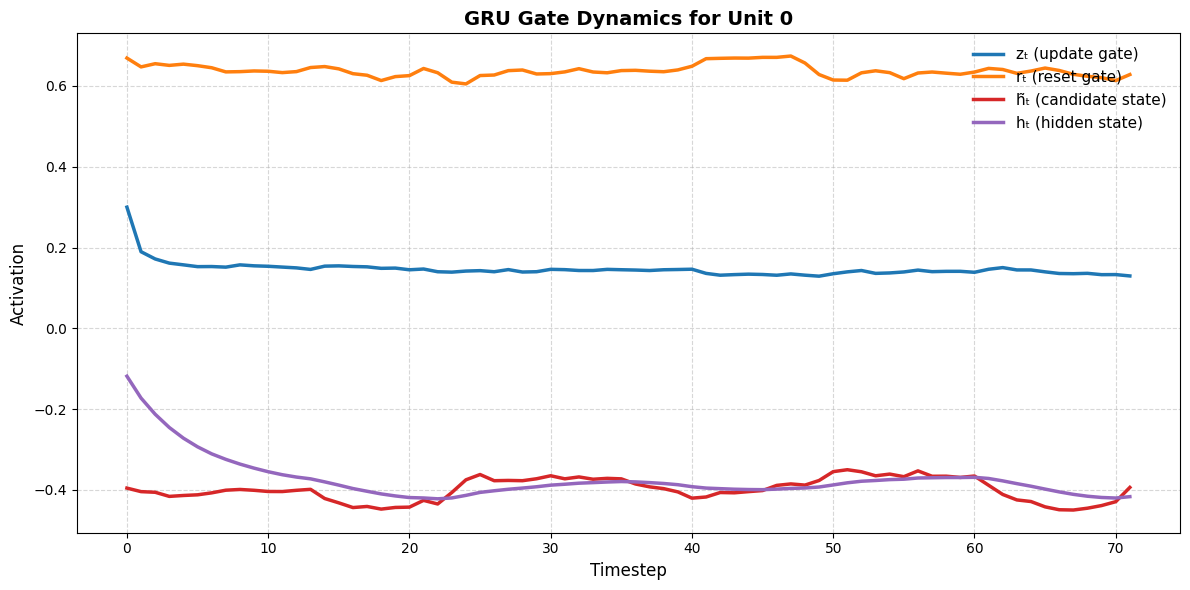

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid nonlinearity
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

# Use one validation sequence from data
sequence = X_val[0:1]          # shape: (1, timesteps, features)
timesteps = sequence.shape[1]

# Access GRU layer and its parameters
gru_layer = gru_model.layers[0]   # <-- fixed name
kernel, recurrent_kernel, bias_full = gru_layer.get_weights()
units = gru_layer.units

# Combine input and recurrent biases
bias = bias_full[0] + bias_full[1]

# Initial hidden state
h_t = np.zeros((1, units))

# Containers for gate and state trajectories
z_traj, r_traj, h_tilde_traj, h_traj = [], [], [], []

# Manual GRU forward pass
for t in range(timesteps):
    x_t = sequence[:, t, :]

    # Update gate z_t
    z_t = sigmoid(x_t @ kernel[:, :units] +
                  h_t @ recurrent_kernel[:, :units] +
                  bias[:units])

    # Reset gate r_t
    r_t = sigmoid(x_t @ kernel[:, units:2 * units] +
                  h_t @ recurrent_kernel[:, units:2 * units] +
                  bias[units:2 * units])

    # Candidate hidden state h̃_t
    h_tilde = np.tanh(x_t @ kernel[:, 2 * units:] +
                      (r_t * h_t) @ recurrent_kernel[:, 2 * units:] +
                      bias[2 * units:])

    # Hidden state update
    h_t = (1.0 - z_t) * h_t + z_t * h_tilde

    # Save trajectories
    z_traj.append(z_t.copy())
    r_traj.append(r_t.copy())
    h_tilde_traj.append(h_tilde.copy())
    h_traj.append(h_t.copy())

# Stack time dimension
z_traj = np.concatenate(z_traj, axis=0)
r_traj = np.concatenate(r_traj, axis=0)
h_tilde_traj = np.concatenate(h_tilde_traj, axis=0)
h_traj = np.concatenate(h_traj, axis=0)

# Plot dynamics for unit 0
plt.figure(figsize=(12, 6))
plt.plot(z_traj[:, 0], label='zₜ (update gate)', color='#1f77b4', linewidth=2.5)
plt.plot(r_traj[:, 0], label='rₜ (reset gate)', color='#ff7f0e', linewidth=2.5)
plt.plot(h_tilde_traj[:, 0], label='h̃ₜ (candidate state)', color='#d62728', linewidth=2.5)
plt.plot(h_traj[:, 0], label='hₜ (hidden state)', color='#9467bd', linewidth=2.5)

plt.xlabel('Timestep', fontsize=12)
plt.ylabel('Activation', fontsize=12)
plt.title('GRU Gate Dynamics for Unit 0', fontsize=14, weight='bold')
plt.legend(loc='upper right', fontsize=11, frameon=False)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import time

# -----------------------
# MNIST dataset loading
# -----------------------
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()
train_images = train_images.reshape(-1, 28, 28, 1).astype("float32") / 255.0
test_images = test_images.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# -----------------------
# CNN architecture for MNIST
# -----------------------
def build_mnist_cnn(input_shape=(28, 28, 1), num_classes=10):
    cnn = models.Sequential()
    cnn.add(layers.Conv2D(32, (3, 3), activation="relu", input_shape=input_shape))
    cnn.add(layers.MaxPooling2D((2, 2)))
    cnn.add(layers.Conv2D(64, (3, 3), activation="relu"))
    cnn.add(layers.MaxPooling2D((2, 2)))
    cnn.add(layers.Flatten())
    cnn.add(layers.Dense(128, activation="relu"))
    cnn.add(layers.Dense(num_classes, activation="softmax"))
    return cnn

mnist_cnn = build_mnist_cnn()
mnist_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the network
start_time = time.time()
history_mnist = mnist_cnn.fit(
    train_images,
    train_labels,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)
training_minutes = (time.time() - start_time) / 60.0

# Evaluate on the test split
test_loss_mnist, test_acc_mnist = mnist_cnn.evaluate(test_images, test_labels)
print(f"MNIST Test Accuracy: {test_acc_mnist * 100:.2f}%, Training Time: {training_minutes:.2f} minutes")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 50s 58ms/step - accuracy: 0.8817 - loss: 0.3820 - val_accuracy: 0.9860 - val_loss: 0.0505
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - accuracy: 0.9837 - loss: 0.0522 - val_accuracy: 0.9857 - val_loss: 0.0454
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 53ms/step - accuracy: 0.9905 - loss: 0.0315 - val_accuracy: 0.9893 - val_loss: 0.0348
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - accuracy: 0.9934 - loss: 0.0216 - val_accuracy: 0.9908 - val_loss: 0.0357
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.9942 - loss: 0.0171 - val_accuracy: 0.9905 - val_loss: 0.0372
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9884 - loss: 0.0367
MNIST Test Accuracy: 99.07%, Training Time: 5.08 minutes


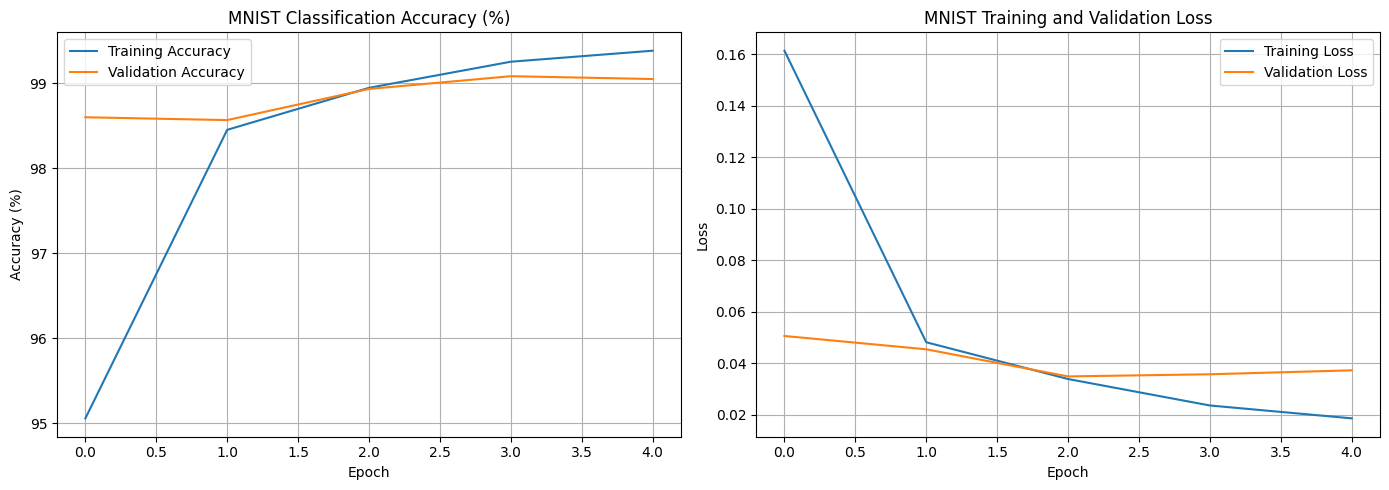

In [18]:
# Side‑by‑side plots: accuracy and loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy (percentage)
axes[0].plot([v * 100 for v in history_mnist.history["accuracy"]], label="Training Accuracy")
axes[0].plot([v * 100 for v in history_mnist.history["val_accuracy"]], label="Validation Accuracy")
axes[0].set_title("MNIST Classification Accuracy (%)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy (%)")
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history_mnist.history["loss"], label="Training Loss")
axes[1].plot(history_mnist.history["val_loss"], label="Validation Loss")
axes[1].set_title("MNIST Training and Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 85ms/step - accuracy: 0.3759 - loss: 1.7096 - val_accuracy: 0.5562 - val_loss: 1.2648
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 94ms/step - accuracy: 0.5923 - loss: 1.1594 - val_accuracy: 0.6278 - val_loss: 1.0498
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 86ms/step - accuracy: 0.6434 - loss: 1.0193 - val_accuracy: 0.6594 - val_loss: 0.9833
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 81ms/step - accuracy: 0.6803 - loss: 0.9203 - val_accuracy: 0.6644 - val_loss: 0.9722
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 59s 83ms/step - accuracy: 0.7079 - loss: 0.8418 - val_accuracy: 0.6952 - val_loss: 0.9088
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6855 - loss: 0.9197
CIFAR-10 Test Accuracy: 67.98%, Training Time: 6.20 minutes


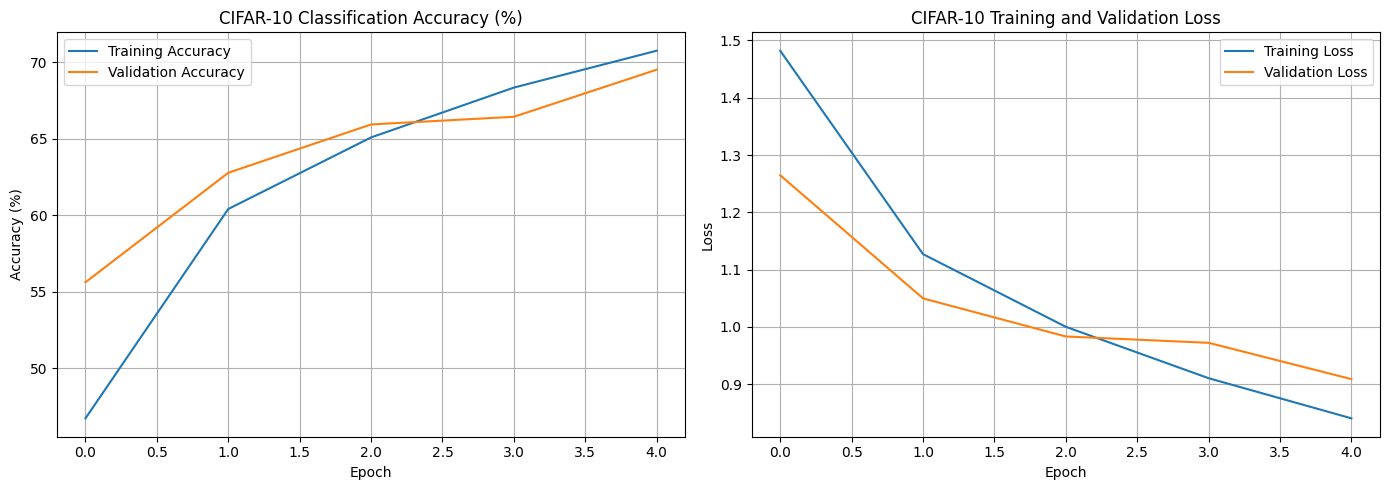

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import time

# -----------------------
# CIFAR‑10 data loading
# -----------------------
(train_images_c, train_labels_c), (test_images_c, test_labels_c) = tf.keras.datasets.cifar10.load_data()
train_images_c = train_images_c.astype("float32") / 255.0
test_images_c = test_images_c.astype("float32") / 255.0

# -----------------------
# CNN definition for CIFAR‑10
# -----------------------
def build_cifar_cnn(input_shape=(32, 32, 3), num_classes=10):
    net = models.Sequential()
    net.add(layers.Conv2D(32, (3, 3), activation="relu", input_shape=input_shape))
    net.add(layers.MaxPooling2D((2, 2)))
    net.add(layers.Conv2D(64, (3, 3), activation="relu"))
    net.add(layers.MaxPooling2D((2, 2)))
    net.add(layers.Flatten())
    net.add(layers.Dense(128, activation="relu"))
    net.add(layers.Dense(num_classes, activation="softmax"))
    return net

cifar_cnn = build_cifar_cnn()
cifar_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# -----------------------
# Training phase
# -----------------------
start_time = time.time()
history_cifar = cifar_cnn.fit(
    train_images_c,
    train_labels_c,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)
cifar_time = (time.time() - start_time) / 60.0  # minutes

# -----------------------
# Evaluation on test set
# -----------------------
test_loss_cifar, test_acc_cifar = cifar_cnn.evaluate(test_images_c, test_labels_c)
print(f"CIFAR-10 Test Accuracy: {test_acc_cifar * 100:.2f}%, Training Time: {cifar_time:.2f} minutes")

# -----------------------
# Accuracy and loss plots
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot (percentage)
axes[0].plot([a * 100 for a in history_cifar.history["accuracy"]], label="Training Accuracy")
axes[0].plot([a * 100 for a in history_cifar.history["val_accuracy"]], label="Validation Accuracy")
axes[0].set_title("CIFAR-10 Classification Accuracy (%)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy (%)")
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history_cifar.history["loss"], label="Training Loss")
axes[1].plot(history_cifar.history["val_loss"], label="Validation Loss")
axes[1].set_title("CIFAR-10 Training and Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()